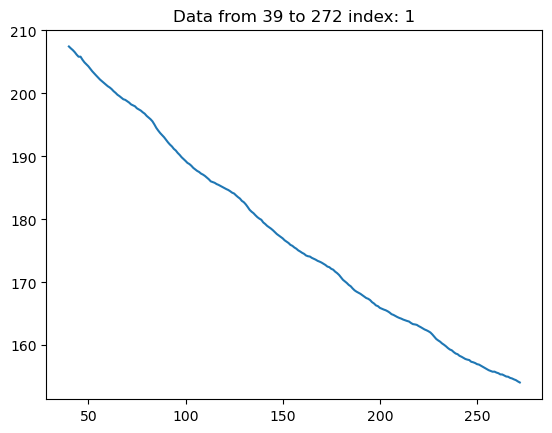

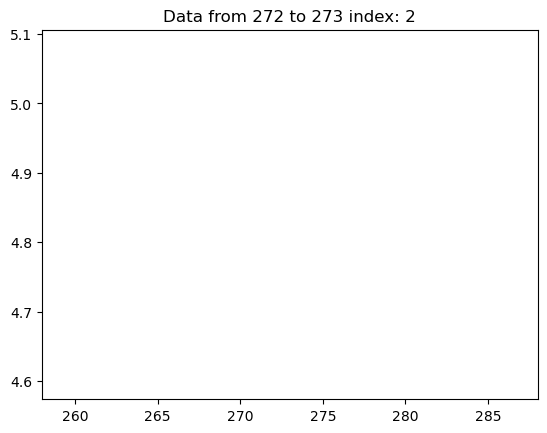

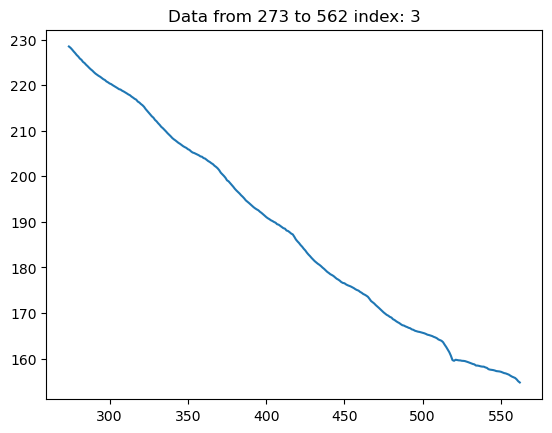

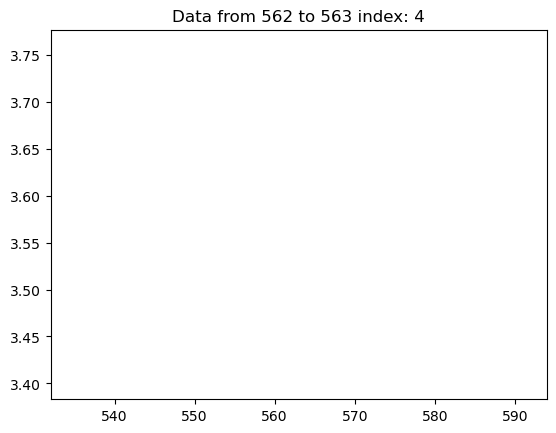

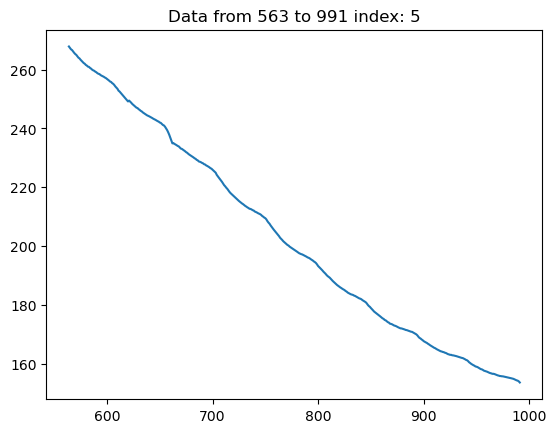

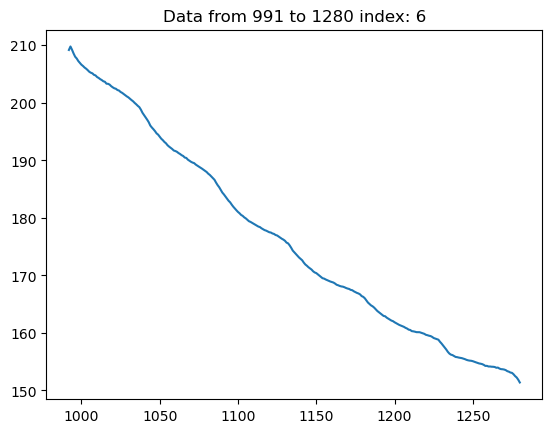

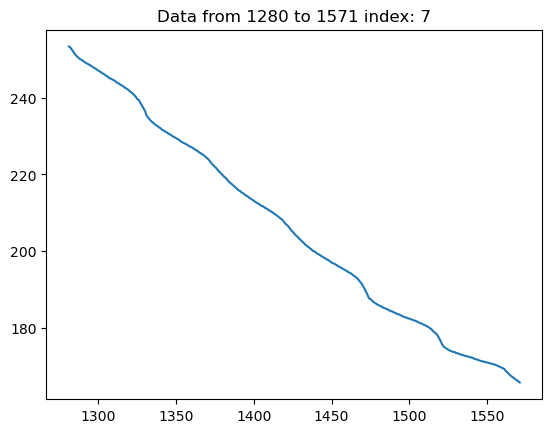

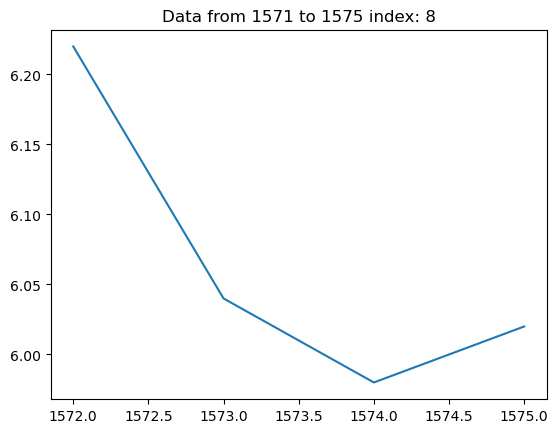

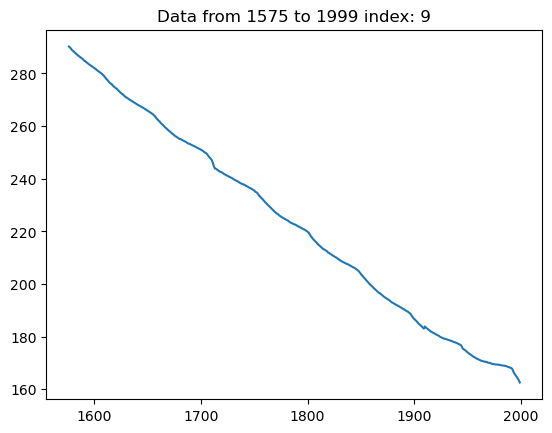

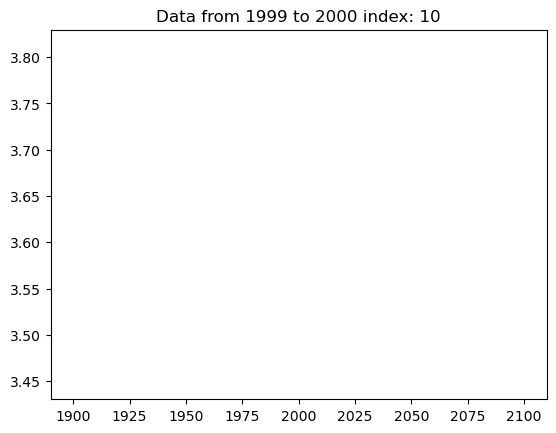

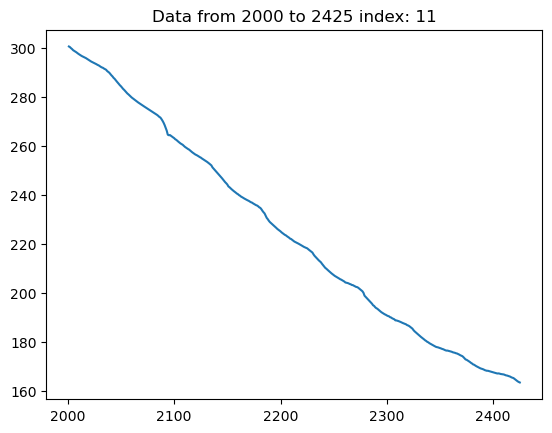

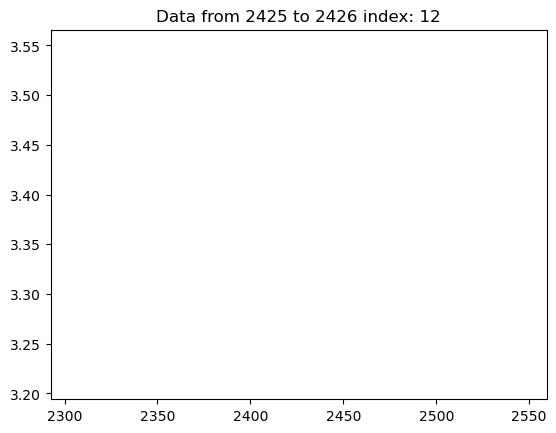

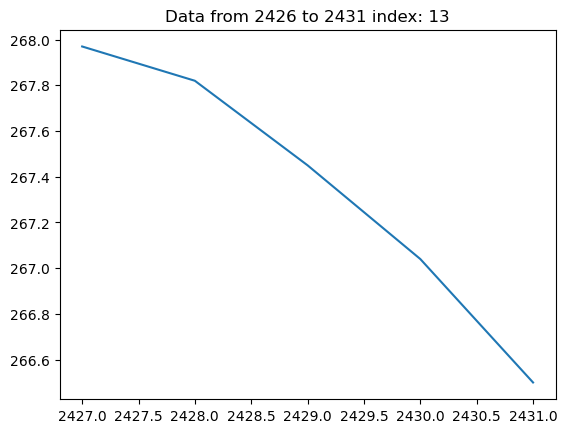

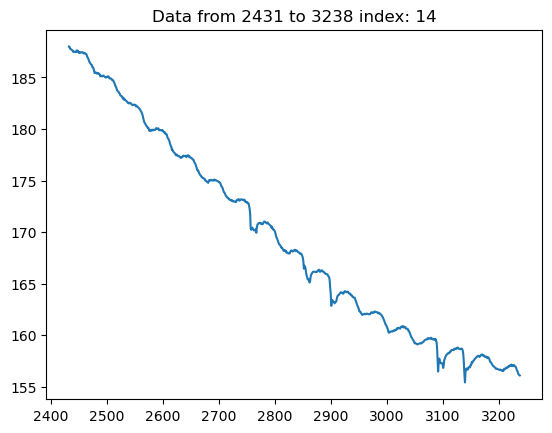

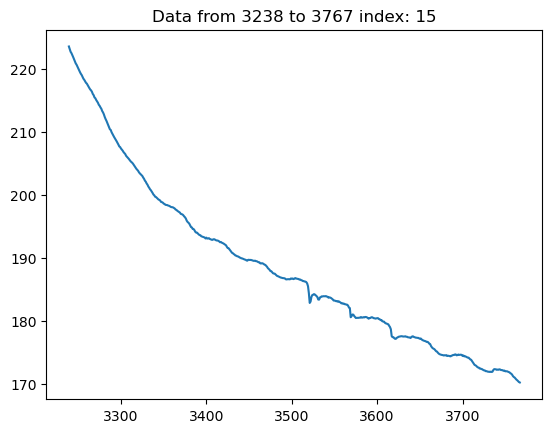

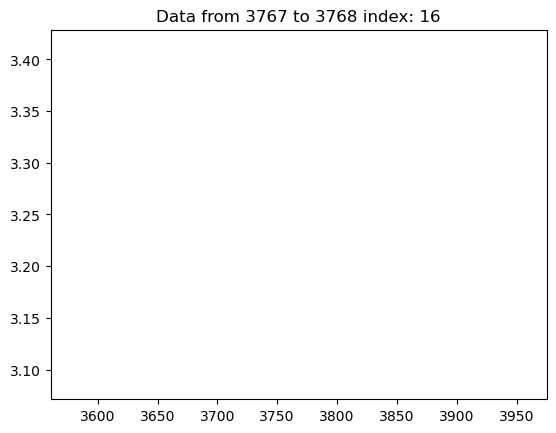

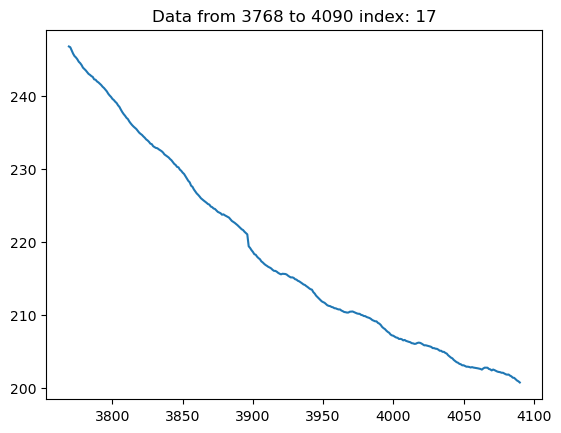

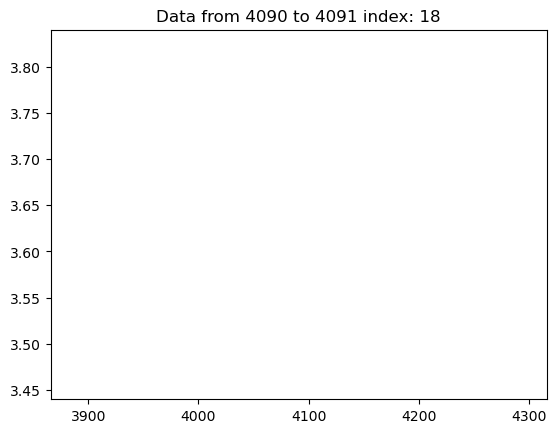

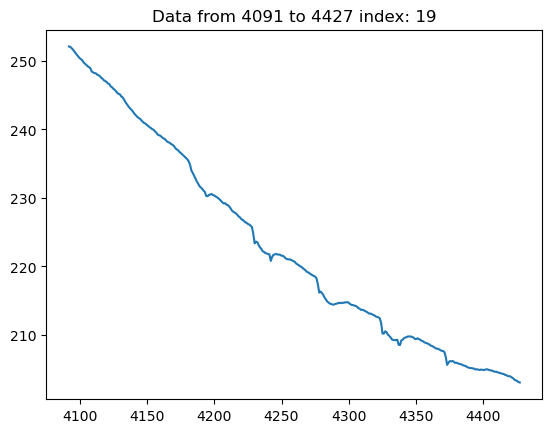

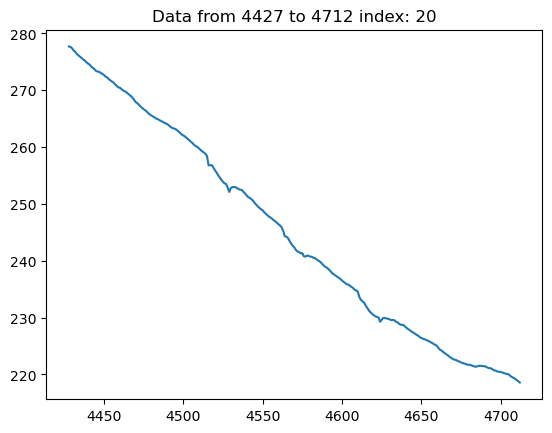

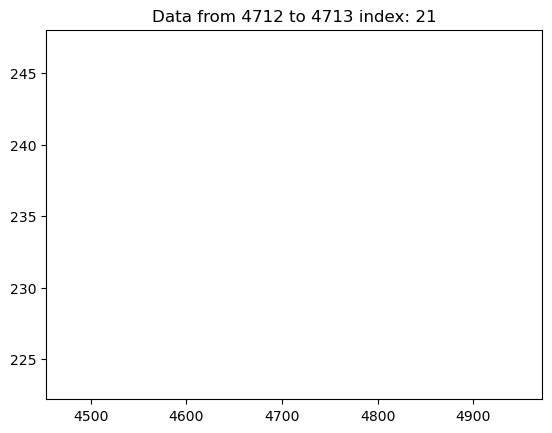

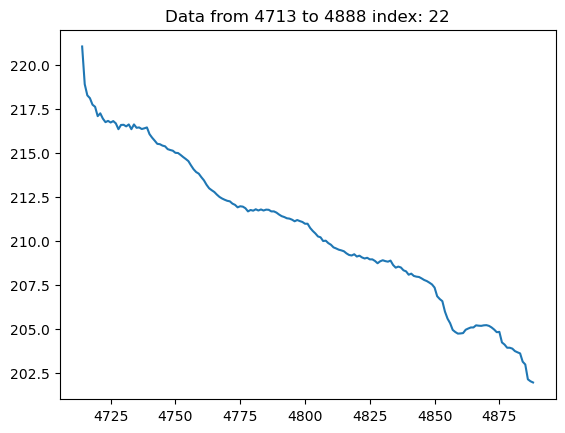

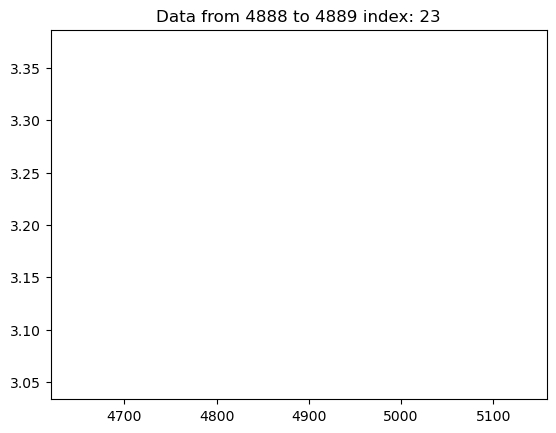

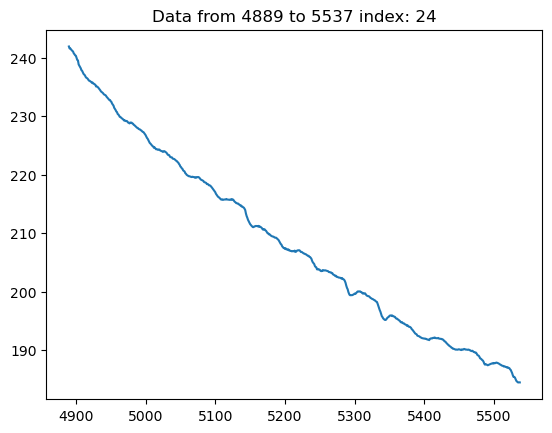

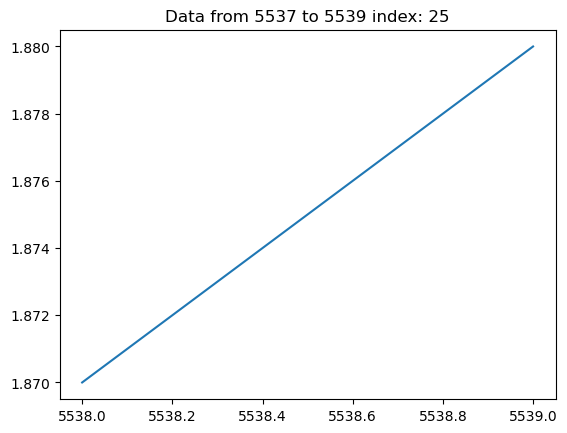

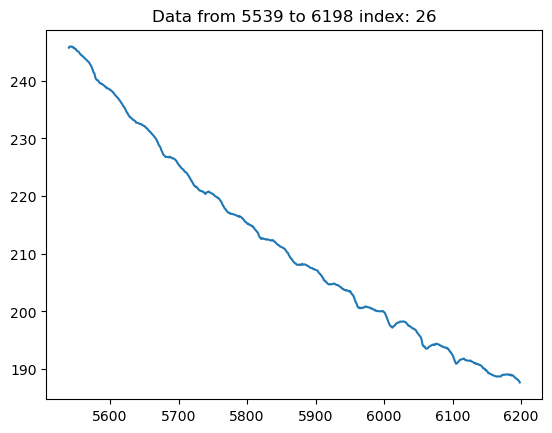

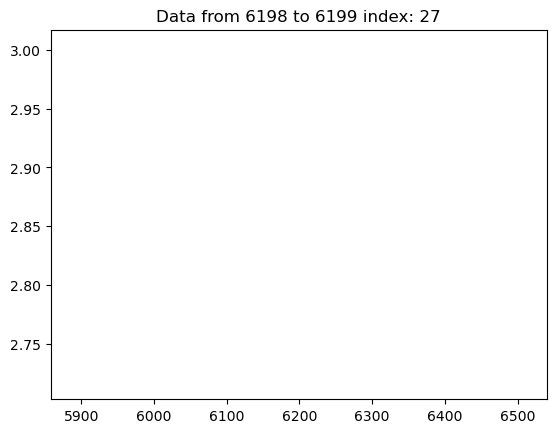

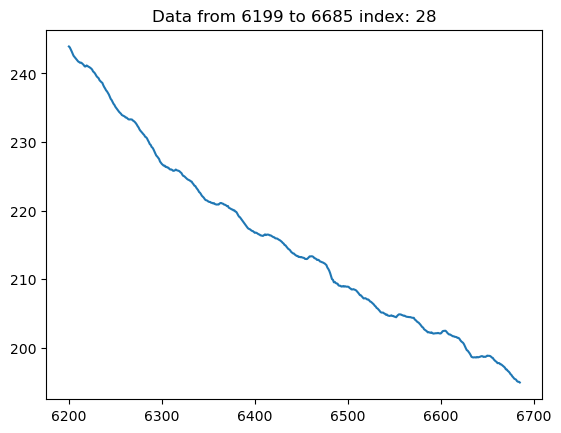

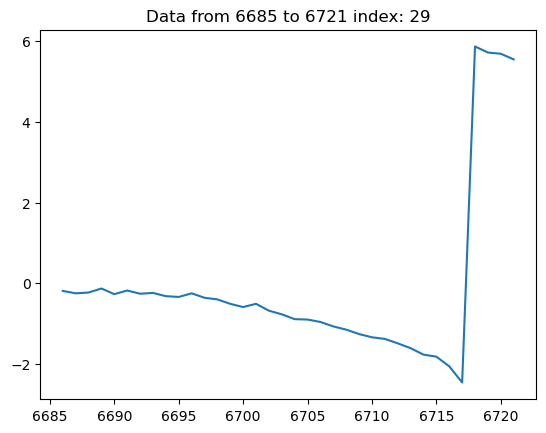

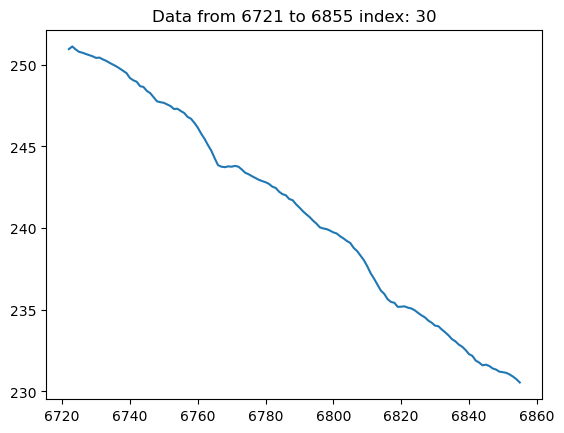

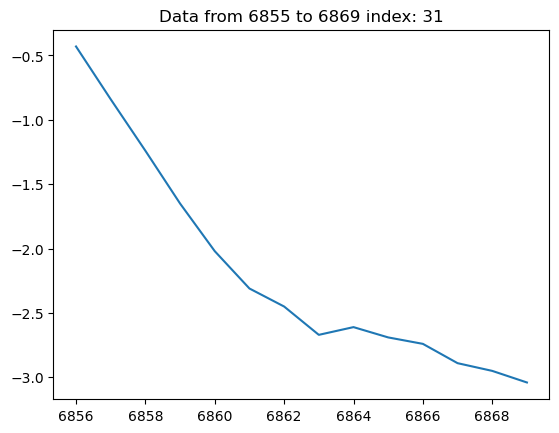

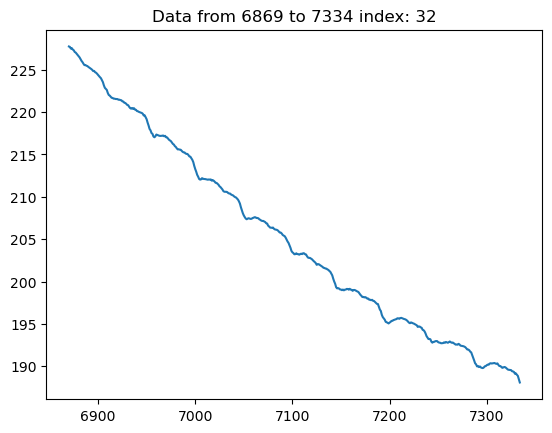

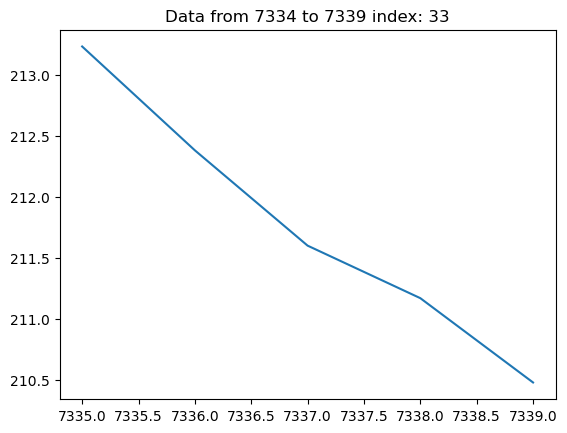

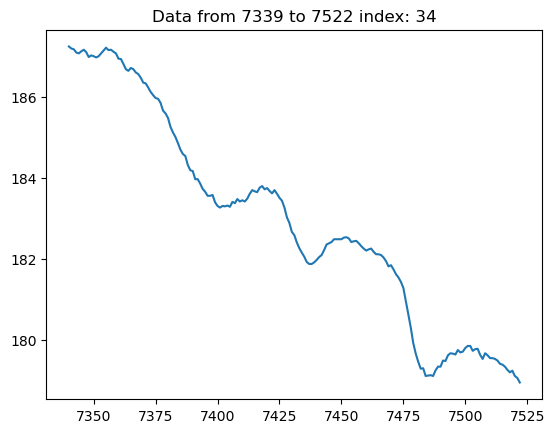

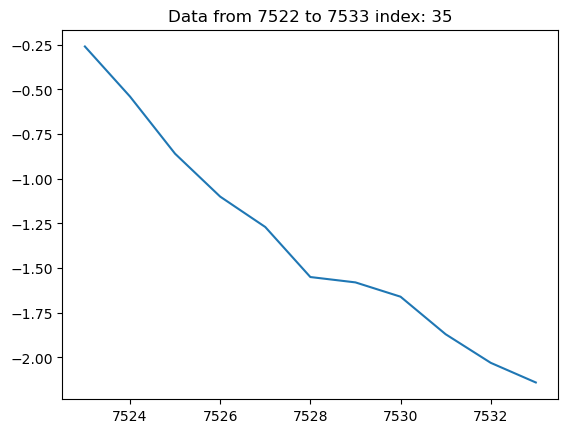

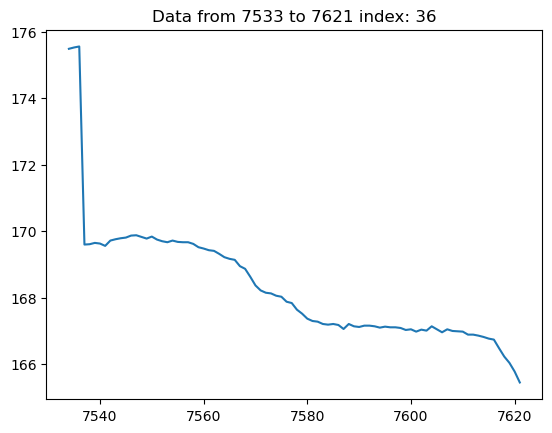

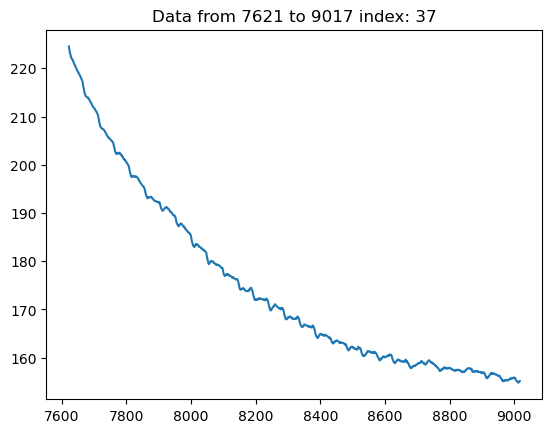

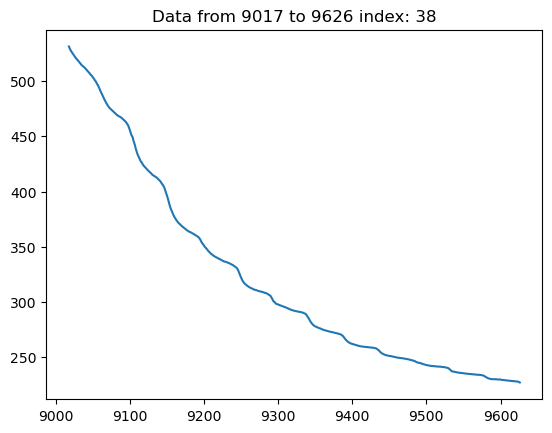

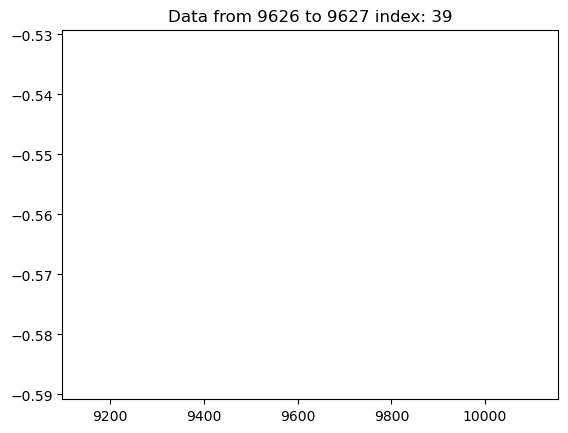

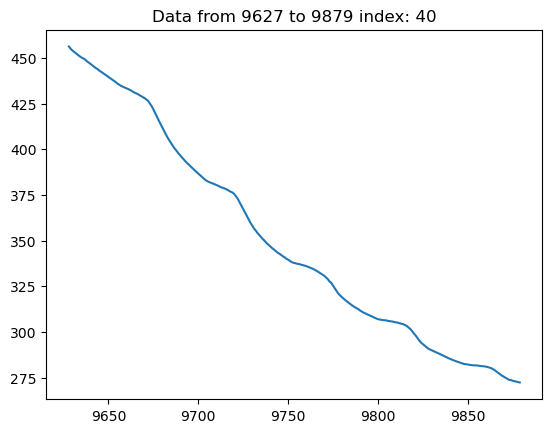

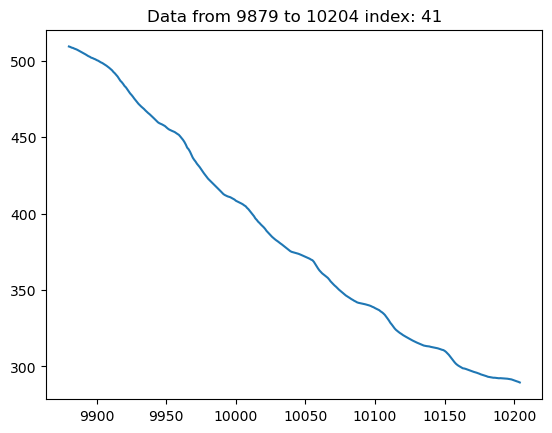

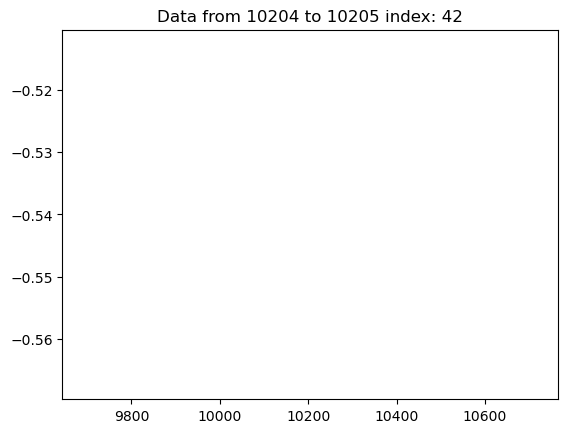

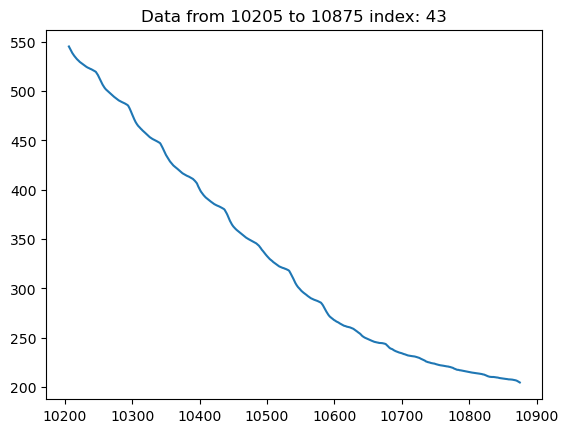

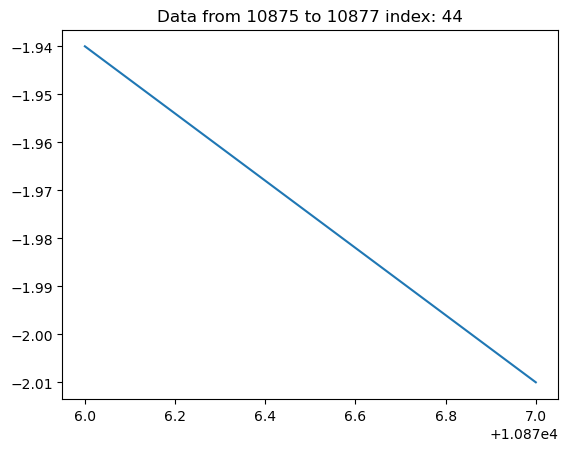

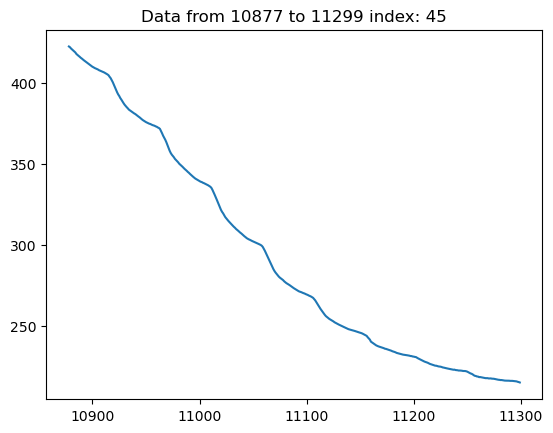

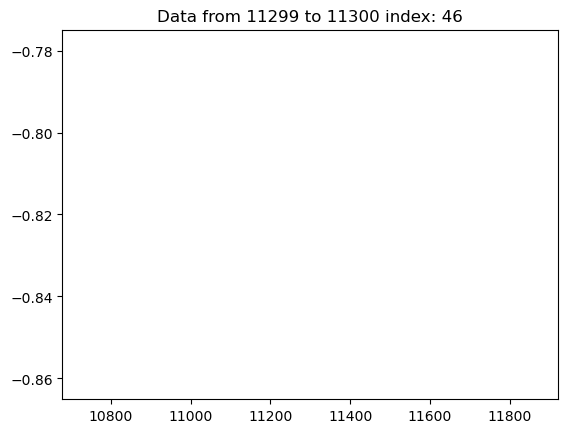

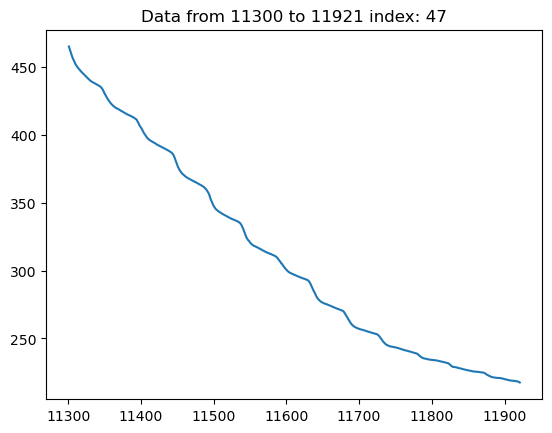

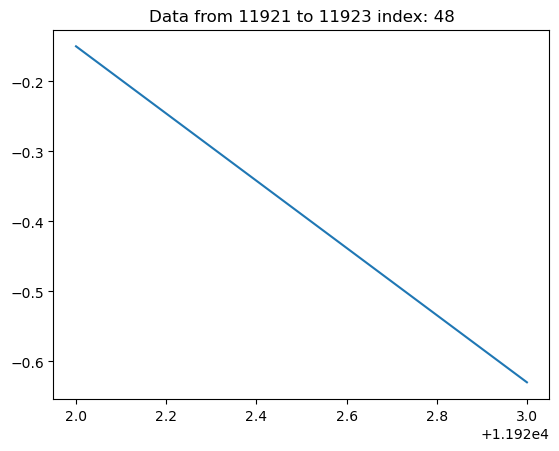

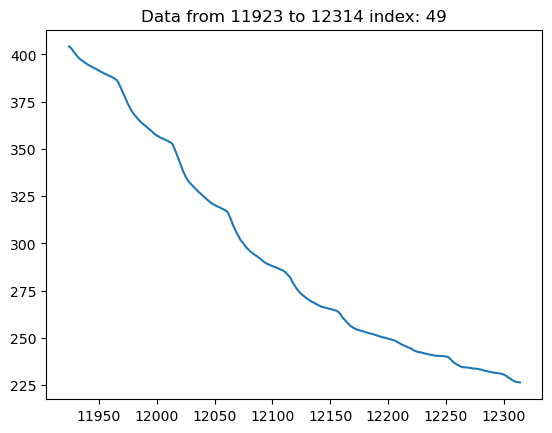

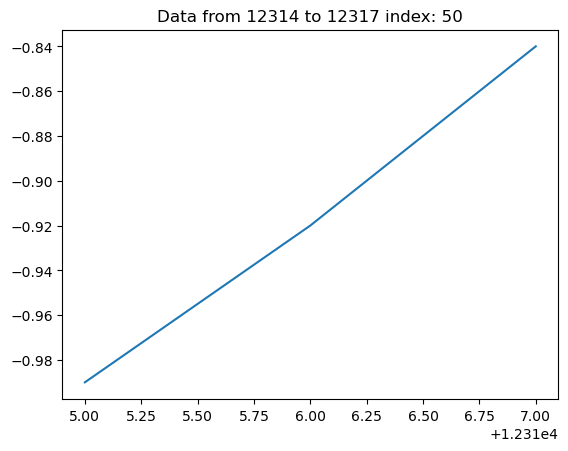

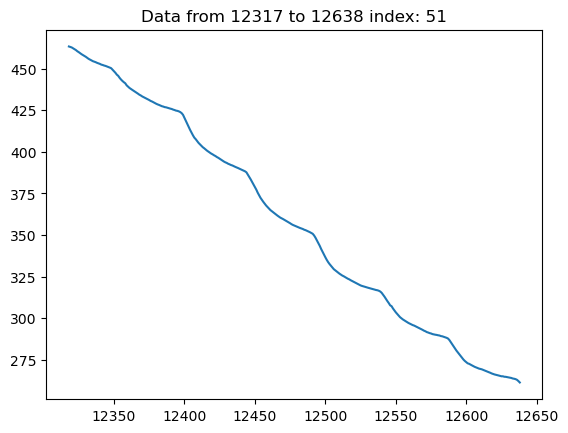

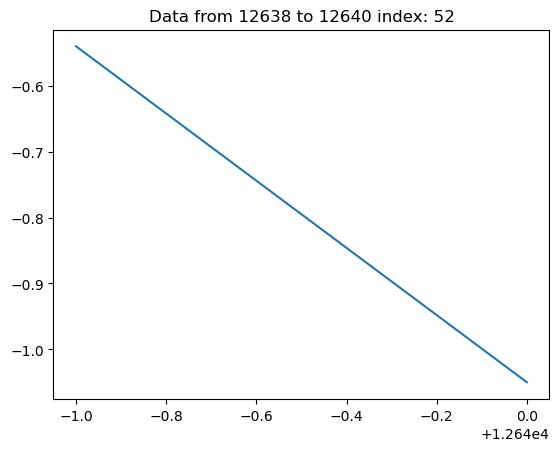

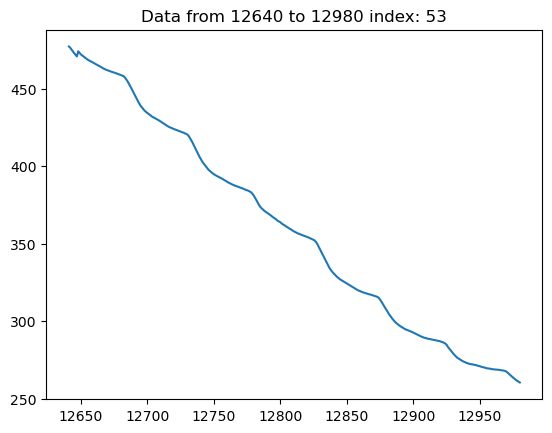

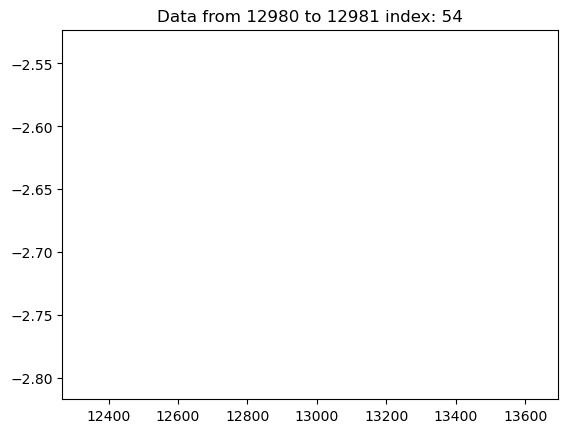

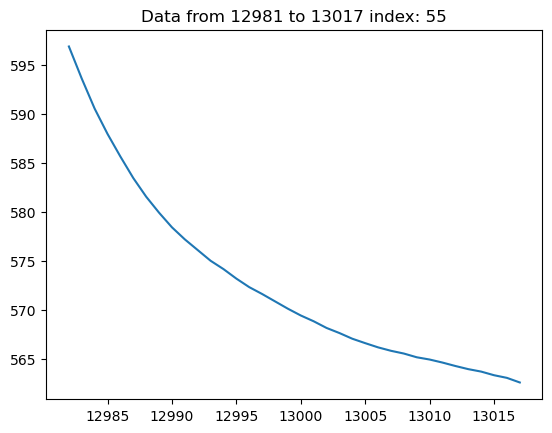

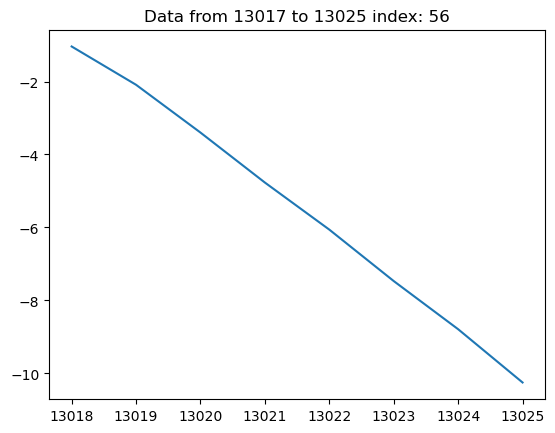

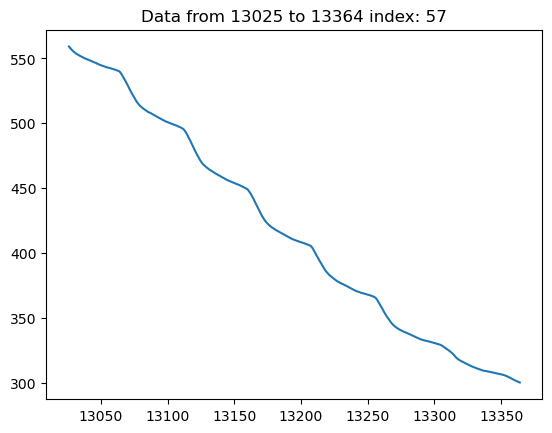

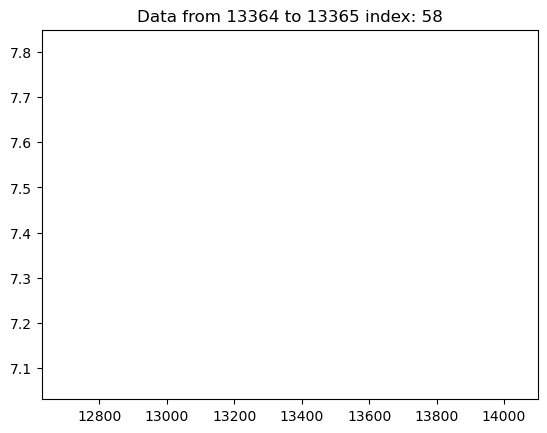

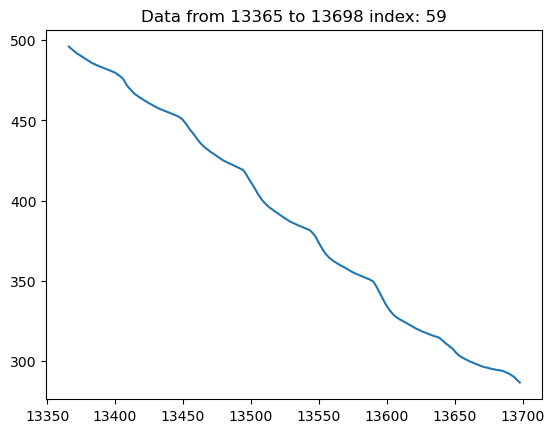

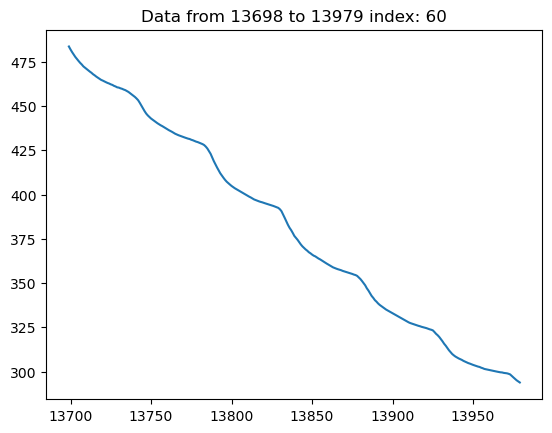

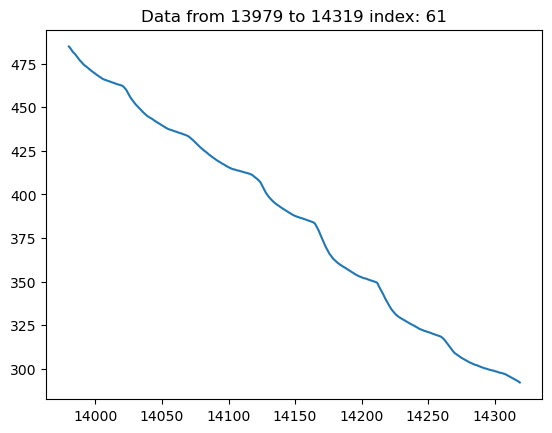

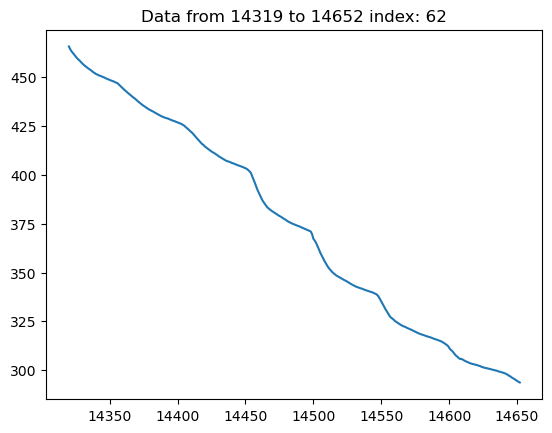

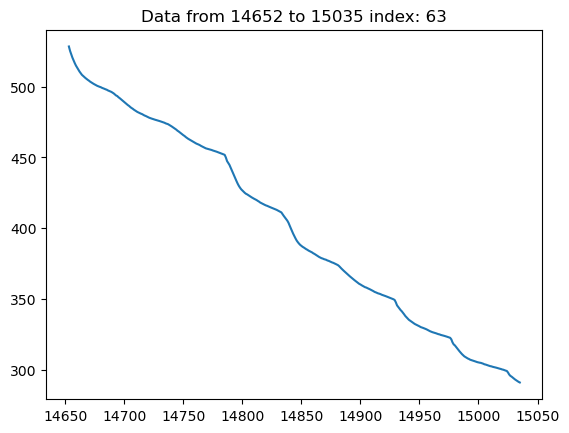

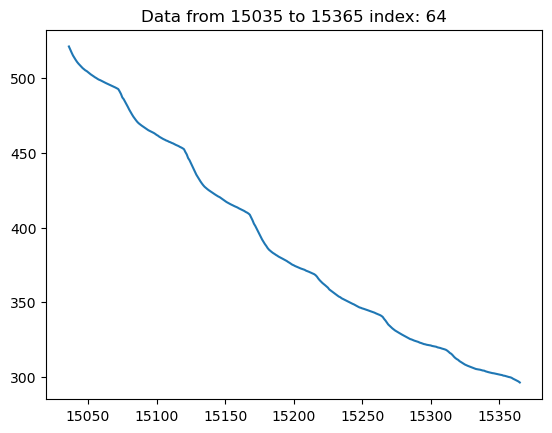

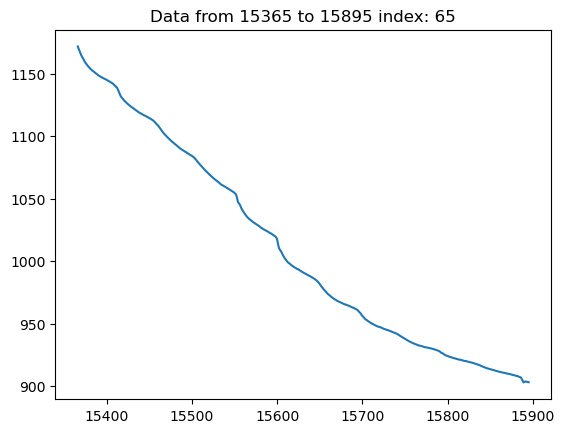

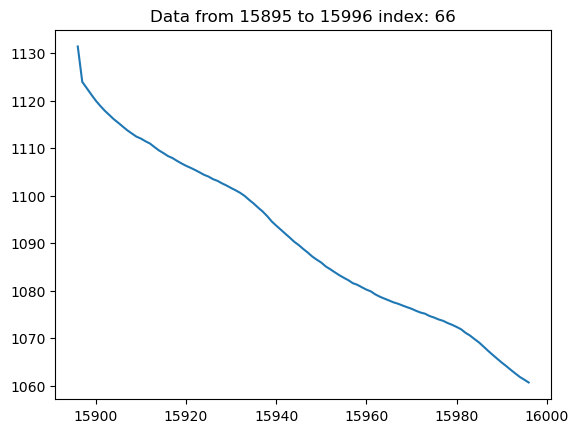

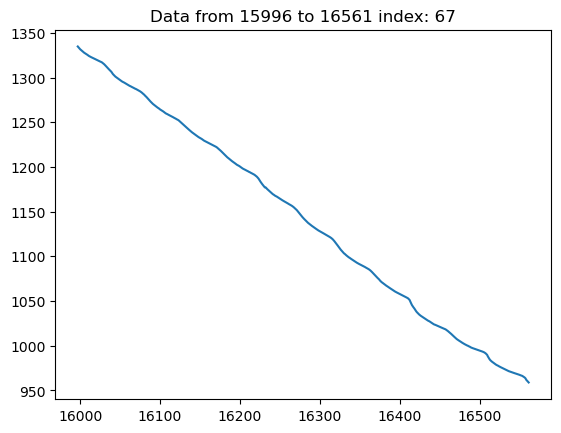

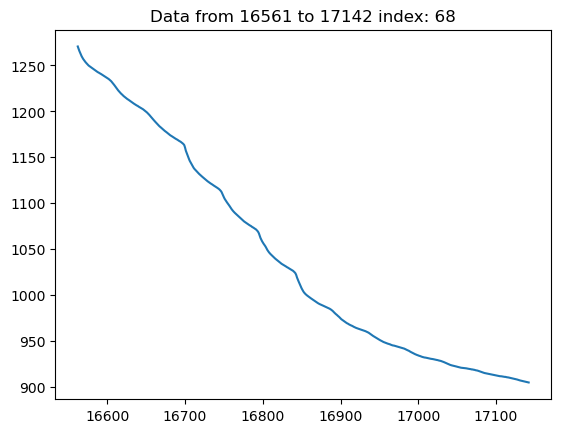

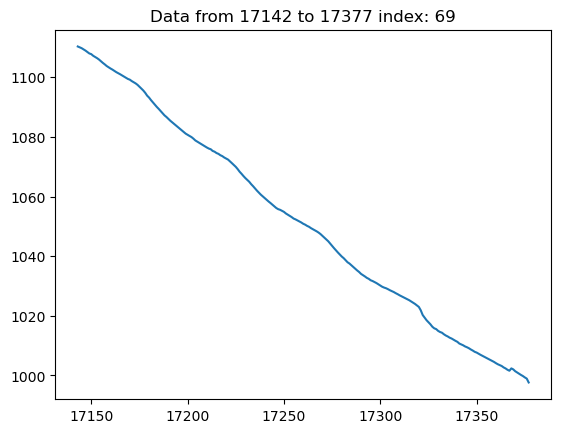

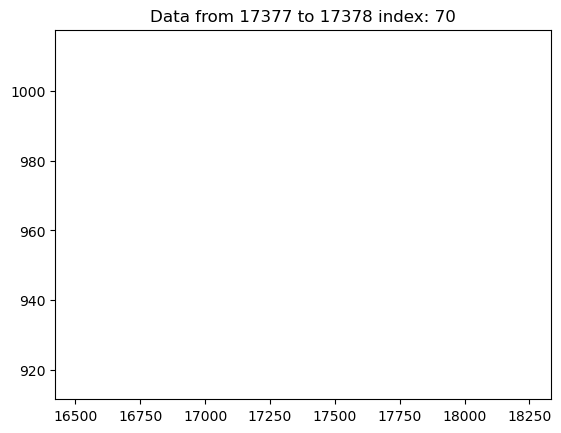

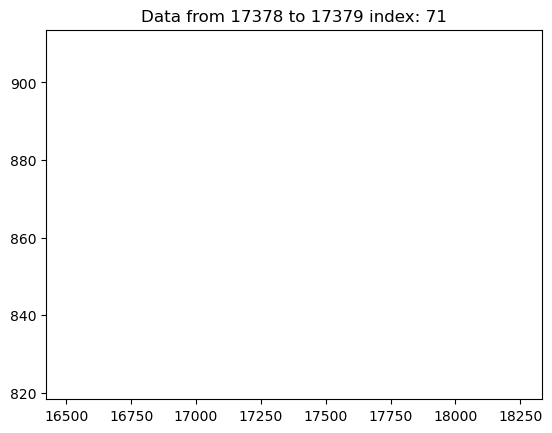

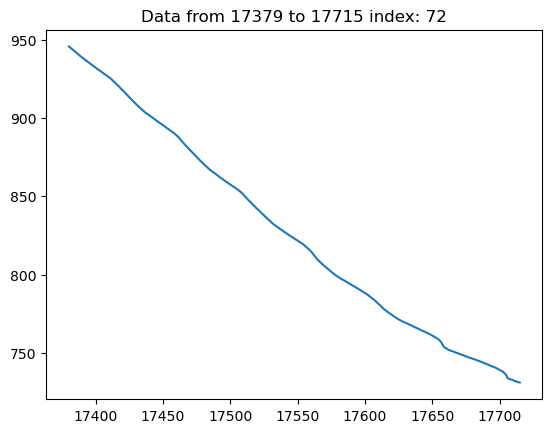

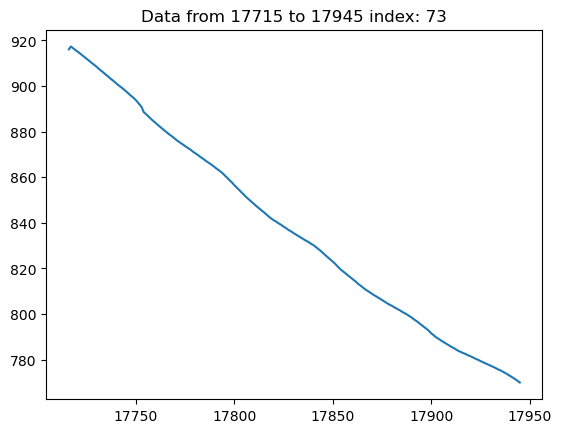

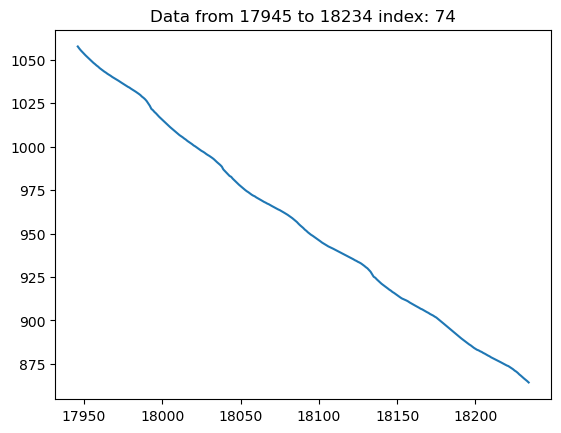

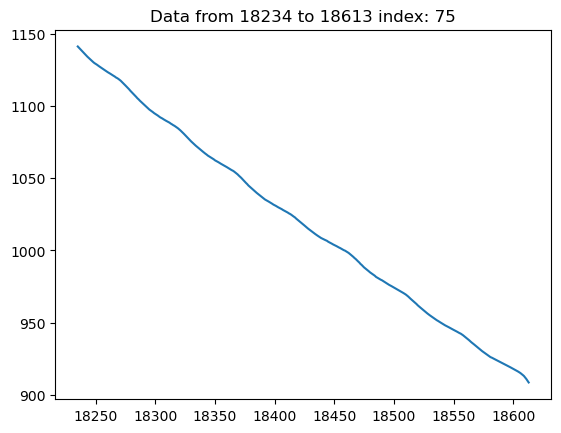

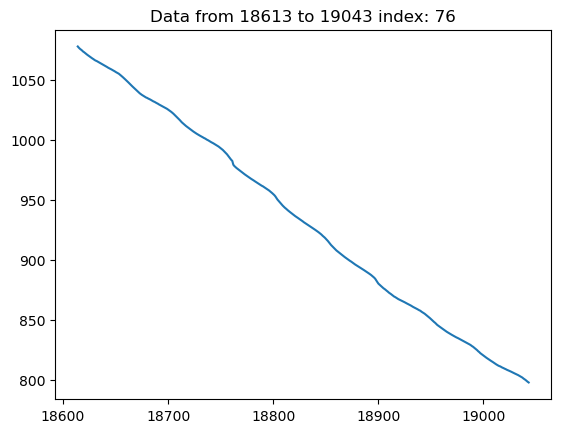

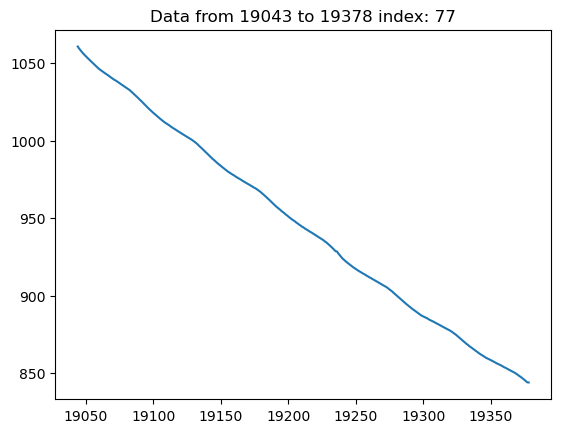

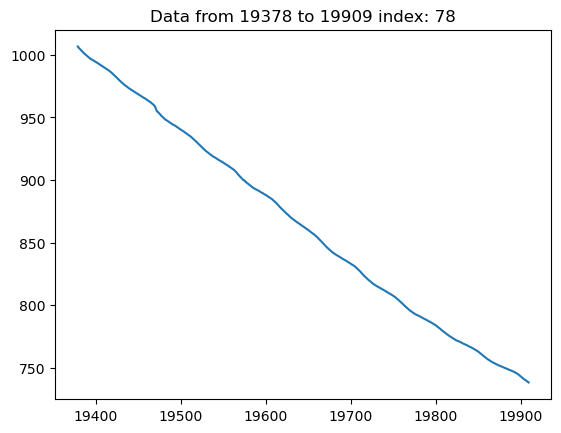

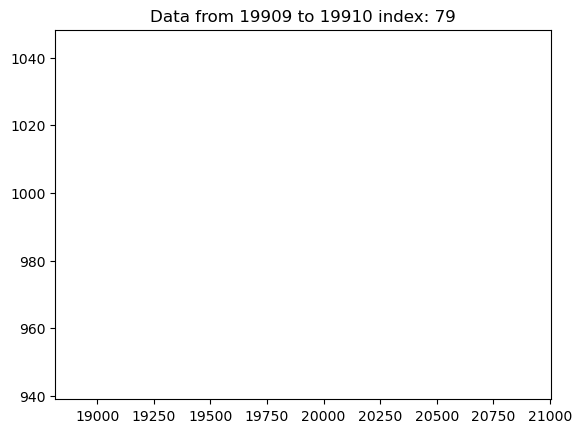

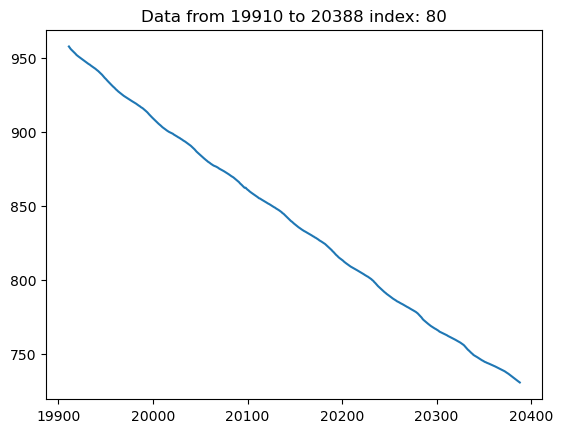

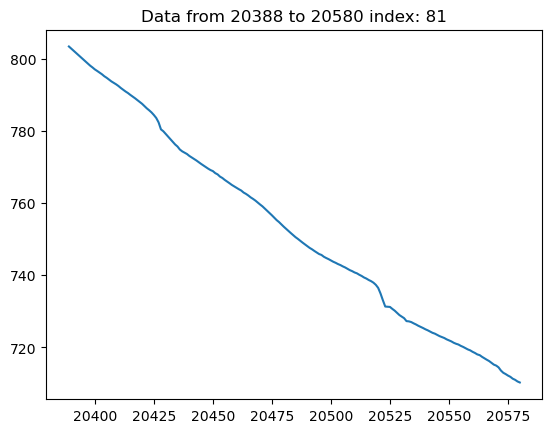

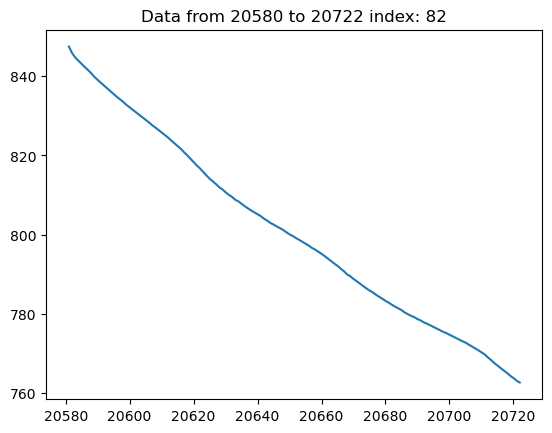

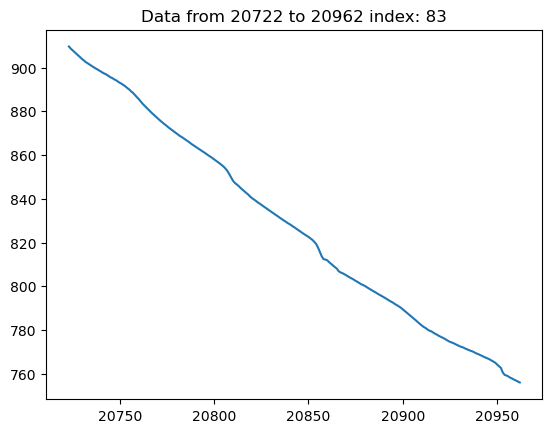

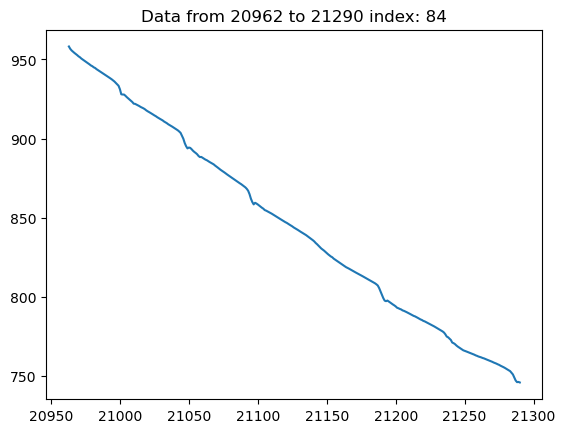

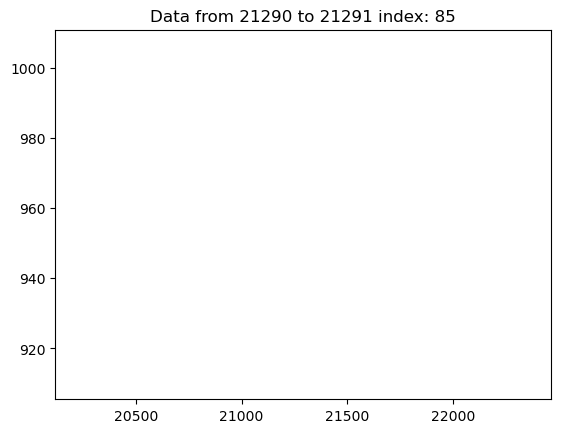

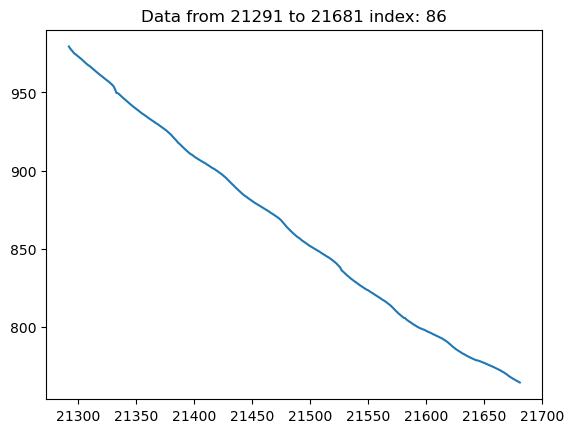

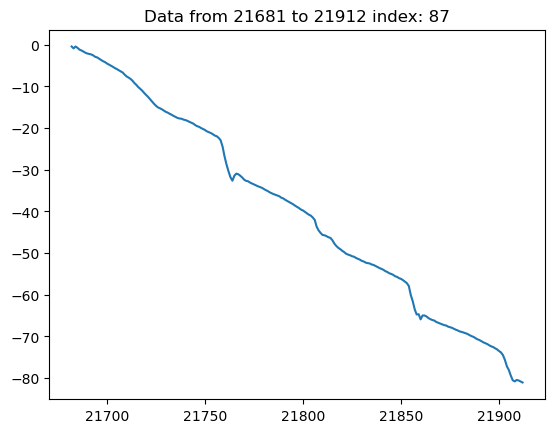

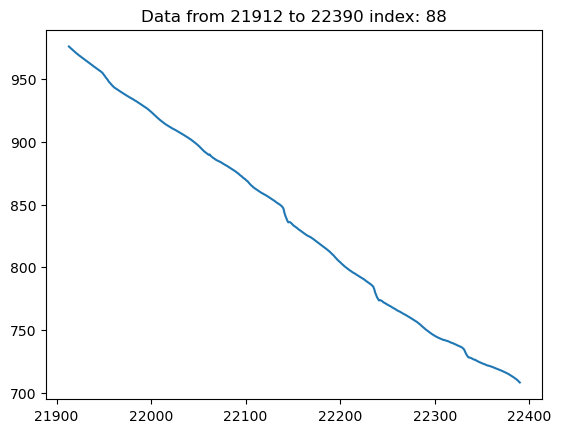

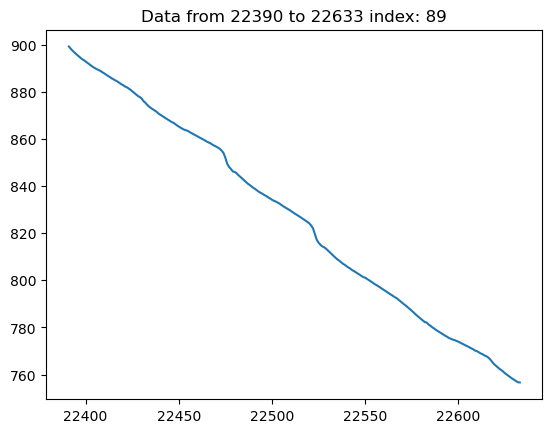

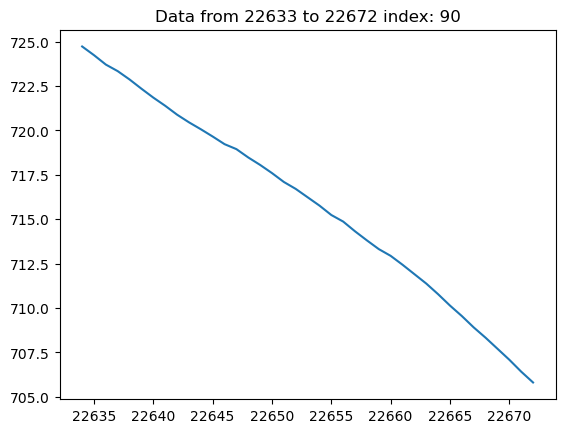

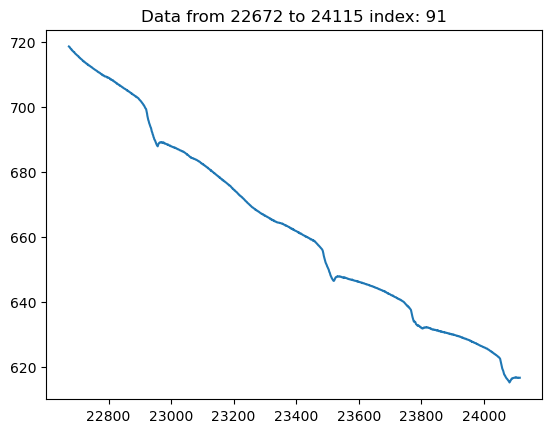

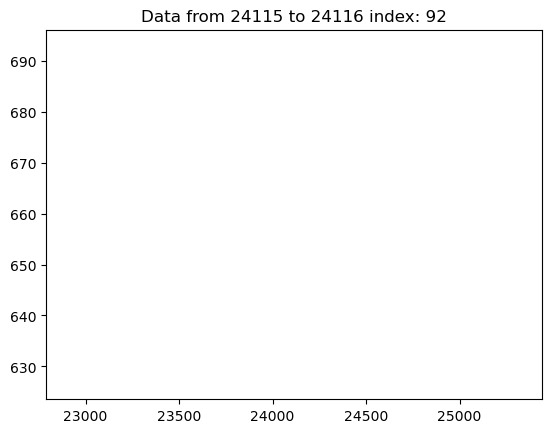

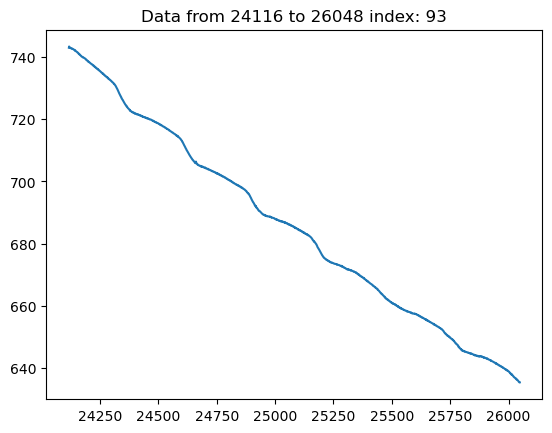

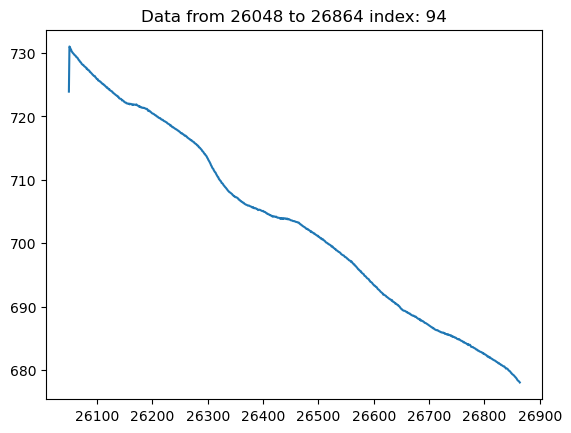

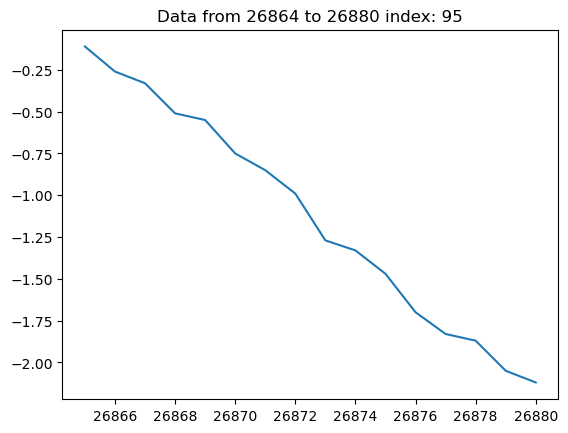

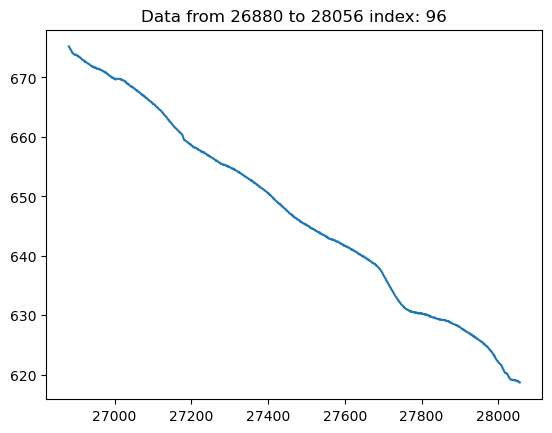

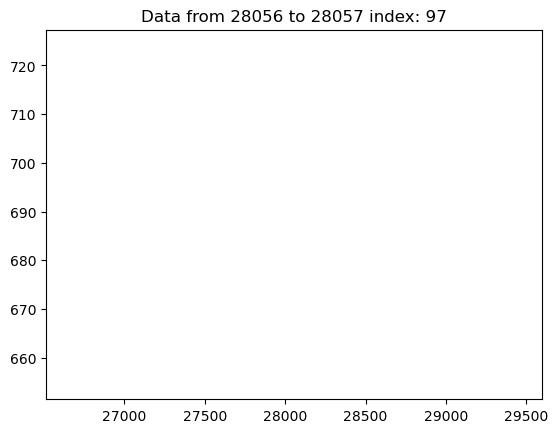

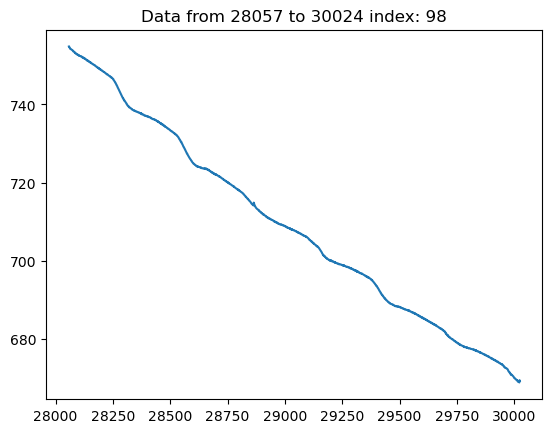

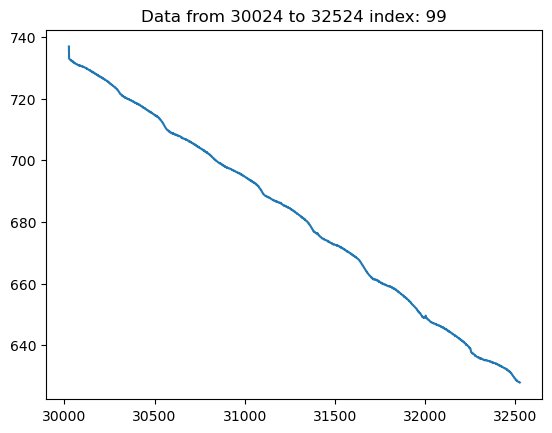

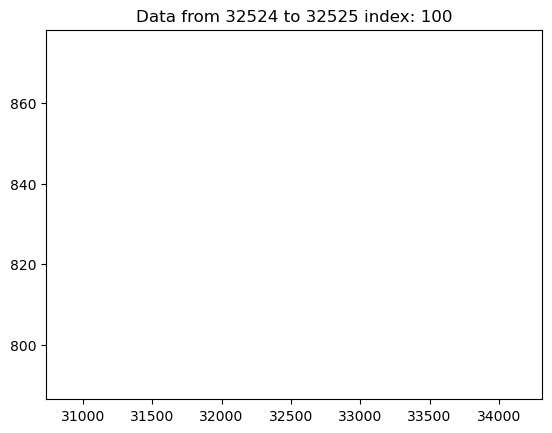

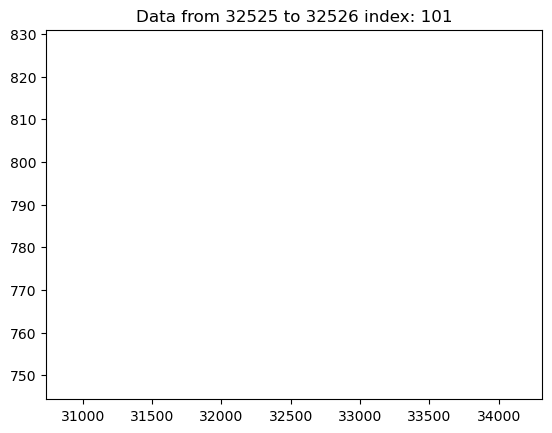

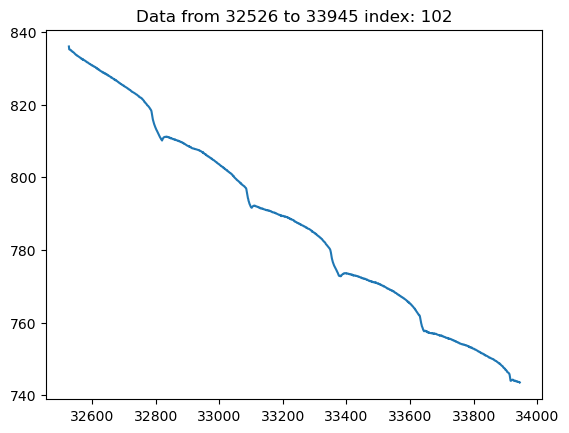

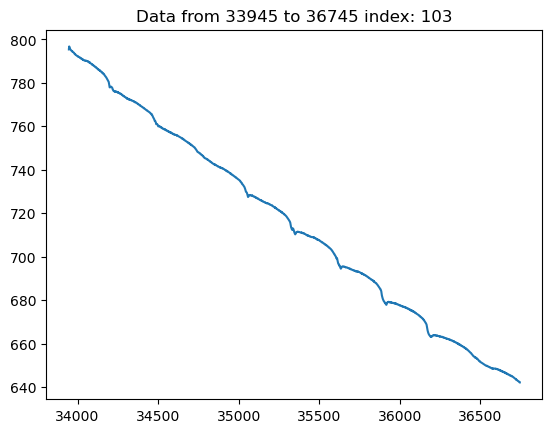

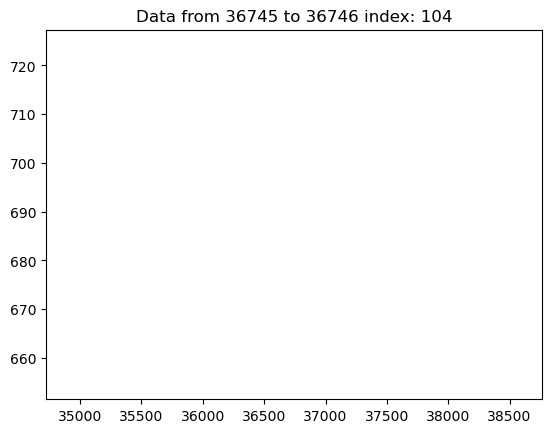

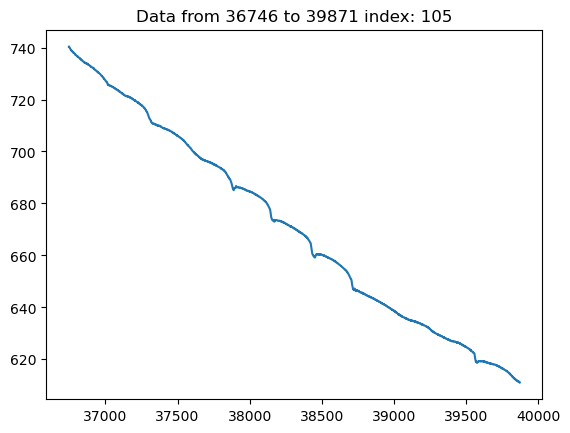

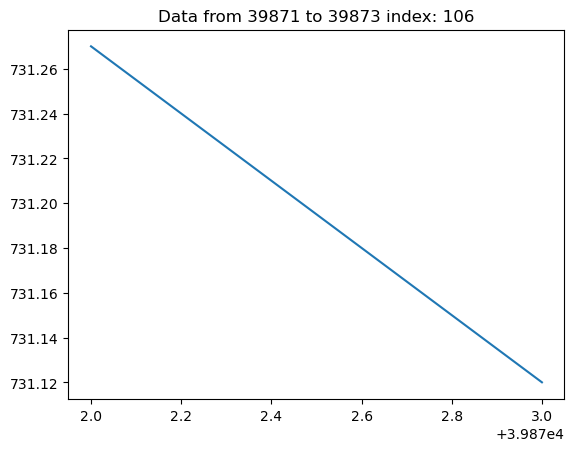

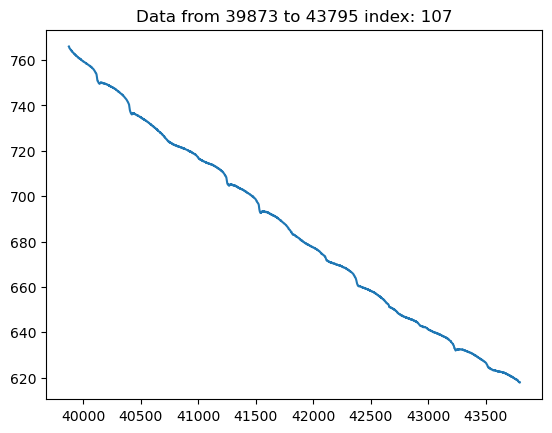

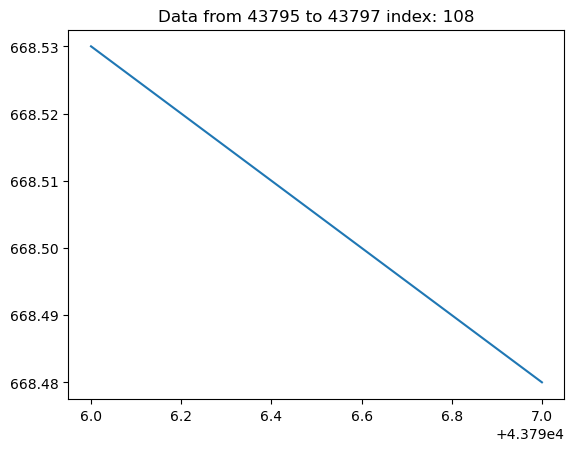

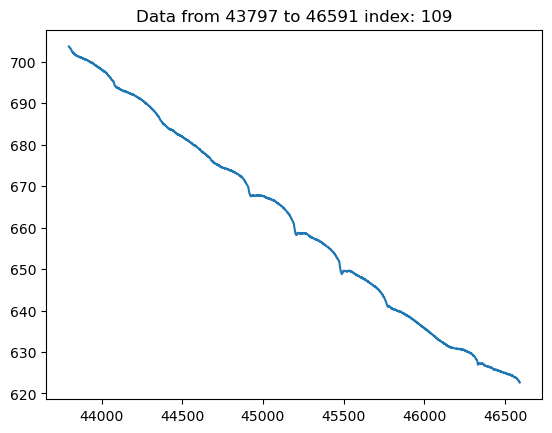

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib inline

data = pd.read_csv("feeds.csv")

# data = data.iloc[:39] - # first 39
#data = data.iloc[40:600]
#print(data.shape)

size = data.shape[0]

jump_val = 10
jump_points = []

field = "field4"

for i in range(size-1): #size-1
  loc = data[field].iloc[i]
  next = data[field].iloc[i+1]

  if abs(loc-next) > jump_val:
    jump_points.append(i+1)

#print(jump_points)

#arr = np.array(jump_points)
#print(np.average(arr))
#print(np.mean(arr))

index = 0
for start, end in zip(jump_points[:-1], jump_points[1:]):
    loc_data = data.iloc[start:end]   # slice from start to end
    index += 1
    #print(loc_data)

    # Example plot
    #plt.figure(figsize=(12,6))
    #plt.subplot(2, 4, 0)
    plt.plot(loc_data["entry_id"], loc_data[field])
    plt.title(f"Data from {start} to {end} index: {index}")
    plt.show()
#plt.scatter(data["entry_id"], data["field1"])
#plt.show()



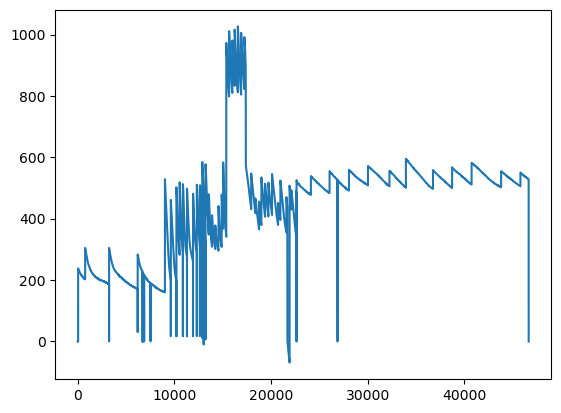

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib inline

data = pd.read_csv("feeds.csv")

# data = data.iloc[:39] - # first 39
#data = data.iloc[40:600]
#print(data.shape)

size = data.shape[0]

field = "field7"

#print(jump_points)

#arr = np.array(jump_points)
#print(np.average(arr))
#print(np.mean(arr))
plt.plot(data[field])
  #plt.title(f"Data from {start} to {end}")
plt.show()



In [ ]:
# KLASSIFITSEERIB ANDMED SARNASUSE JÄRGI

import pandas as pd

data = pd.read_csv("feeds.csv")

size = data.shape[0]
jump_val = 10
jump_points = []

field = "field2"

# --- Find jump points ---
for i in range(size - 1):
    loc = data[field].iloc[i]
    nxt = data[field].iloc[i + 1]
    if abs(loc - nxt) > jump_val:
        jump_points.append(i + 1)

similarity = 0.95

groups = {}
used = set()

group_id = 0

# --- Build groups based on MEAN comparison ---
for i in range(len(jump_points)):

    if i in used:
        continue

    # Start new group
    groups[group_id] = [i]
    used.add(i)

    # Values belonging to this group (for dynamic mean update)
    group_values = [data[field].iloc[jump_points[i]]]

    for j in range(i + 1, len(jump_points)):
        if j not in used:

            candidate_value = data[field].iloc[jump_points[j]]
            group_mean = sum(group_values) / len(group_values)

            if (candidate_value / group_mean) >= similarity:
                groups[group_id].append(j)
                used.add(j)

                # update mean source
                group_values.append(candidate_value)

    group_id += 1

# --- Print results ---
for g in groups:
    print(f"{g}: {groups[g]}")
